## 1. Carga del dataset original

In [0]:
from pyspark.sql import functions as F

df = spark.table("games_catalog.games_db.games_features")
df.printSchema()
df.show(5)


root
 |-- QueryName: string (nullable = true)
 |-- ReleaseDate: string (nullable = true)
 |-- Metacritic: integer (nullable = true)
 |-- RecommendationCount: integer (nullable = true)
 |-- IsFree: boolean (nullable = true)
 |-- GenreIsNonGame: boolean (nullable = true)
 |-- GenreIsIndie: boolean (nullable = true)
 |-- GenreIsAction: boolean (nullable = true)
 |-- GenreIsAdventure: boolean (nullable = true)
 |-- GenreIsCasual: boolean (nullable = true)
 |-- GenreIsStrategy: boolean (nullable = true)
 |-- GenreIsRPG: boolean (nullable = true)
 |-- GenreIsSimulation: boolean (nullable = true)
 |-- GenreIsEarlyAccess: boolean (nullable = true)
 |-- GenreIsFreeToPlay: boolean (nullable = true)
 |-- GenreIsSports: boolean (nullable = true)
 |-- GenreIsRacing: boolean (nullable = true)
 |-- GenreIsMassivelyMultiplayer: boolean (nullable = true)
 |-- PriceInitial: double (nullable = true)

+--------------------+-----------+----------+-------------------+------+--------------+------------+-----

2. Conversión de la columna de fecha
3. Derivación de columnas temporales
4. Validación visual de las columnas derivadas

In [0]:
from pyspark.sql import functions as F

df_fecha = (
    df
    .withColumn(
        "fecha",
        F.try_to_date(
            F.col("ReleaseDate"),
            "MMM d yyyy"
        )
    )
    .withColumn(
        "anio",
        F.year("fecha")
    )
    .withColumn(
        "mes",
        F.month("fecha")
    )
    .withColumn(
        "dia",
        F.dayofmonth("fecha")
    )
    .withColumn(
        "dia_semana",
        F.expr("EXTRACT(DOW FROM fecha)")
    )
    .withColumn(
        "nombre_dia",
        F.date_format("fecha", "EEEE")
    )
)

display(
    df_fecha.select(
        "ReleaseDate",
        "fecha",
        "anio",
        "mes",
        "dia",
        "dia_semana",
        "nombre_dia"
    ).limit(20)
)

ReleaseDate,fecha,anio,mes,dia,dia_semana,nombre_dia
Nov 1 2000,2000-11-01,2000,11,1,4,Wednesday
Apr 1 1999,1999-04-01,1999,4,1,5,Thursday
May 1 2003,2003-05-01,2003,5,1,5,Thursday
Jun 1 2001,2001-06-01,2001,6,1,6,Friday
Nov 1 1999,1999-11-01,1999,11,1,2,Monday
Nov 1 2000,2000-11-01,2000,11,1,4,Wednesday
Nov 8 1998,1998-11-08,1998,11,8,1,Sunday
Mar 1 2004,2004-03-01,2004,3,1,2,Monday
Mar 1 2004,2004-03-01,2004,3,1,2,Monday
Jun 1 2001,2001-06-01,2001,6,1,6,Friday


5. Almacenamiento de la tabla enriquecida

In [0]:
# Guardar tabla enriquecida
df_fecha.write.mode("overwrite").format("delta").saveAsTable(
    "games_catalog.games_db.games_features_enriquecida"
)

anio / mes: te permiten ver estacionalidad y tendencias a lo largo del tiempo.

dia / dia_semana / nombre_dia: sirven para ver patrones semanales

6. Resumen mensual de los datos

In [0]:
%sql
USE games_catalog.games_db;

CREATE OR REPLACE TABLE resumen_mensual AS
SELECT
  anio,
  mes,
  COUNT(*) AS total_juegos,
  AVG(Metacritic) AS metacritic_promedio,
  AVG(PriceInitial) AS precio_promedio,
  SUM(CASE WHEN IsFree THEN 1 ELSE 0 END) AS juegos_gratis,
  SUM(CASE WHEN NOT IsFree THEN 1 ELSE 0 END) AS juegos_de_pago
FROM games_features_enriquecida
GROUP BY anio, mes
ORDER BY anio, mes;


num_affected_rows,num_inserted_rows


### Explicación de las columnas derivadas

**fecha:** Permite organizar la información en el tiempo y realizar análisis históricos, tendencias y comparaciones entre períodos. Es la base del análisis temporal.

**anio:** Facilita evaluar la evolución de los datos a lo largo de los años e identificar cambios o comportamientos a largo plazo.

**mes:** Permite analizar la estacionalidad, identificando los meses con mayor o menor número de registros.

**dia:** Ayuda a realizar un análisis detallado dentro de cada mes y observar comportamientos específicos por fecha.

**dia_semana:** Permite detectar patrones semanales, como qué días se presenta mayor actividad o eventos.

**nombre_dia:** Mejora la interpretación visual de los análisis al mostrar el día de forma legible para el usuario.


Se observa cuántos juegos se lanzan por mes, su precio y puntuación promedio, y la proporción de juegos gratis vs de pago.

## Nueva tabla: resumen mensual de los datos


In [0]:
%sql
SELECT * FROM resumen_mensual LIMIT 10;


anio,mes,total_juegos,metacritic_promedio,precio_promedio,juegos_gratis,juegos_de_pago
null,null,725,2.533793103448276,1.3096137931034488,61,664
1997,6,1,0.0,9.99,0,1
1998,11,1,96.0,9.99,0,1
1999,4,1,0.0,4.99,0,1
1999,11,1,0.0,4.99,0,1
2000,11,2,44.0,7.49,0,2
2001,3,1,81.0,19.99,1,0
2001,6,2,35.5,4.99,0,2
2001,12,1,0.0,19.99,1,0
2003,5,1,79.0,4.99,0,1


Se construyó una nueva tabla agregada por año y mes a partir de la tabla enriquecida, con el fin de analizar la cantidad de juegos lanzados por período, así como promedios de puntuación y precios, y la distribución entre juegos gratuitos y de pago. Esta tabla permite observar tendencias temporales y patrones de comportamiento a lo largo del tiempo.


## Limpieza de datos: evidencia antes y después

Dataset ANTES de la limpieza

In [0]:
df_before = spark.table("games_catalog.games_db.games_features_enriquecida")

display(
    df_before.select(
        "QueryName",
        "ReleaseDate",
        "Metacritic",
        "PriceInitial"
    ).limit(20)
)


QueryName,ReleaseDate,Metacritic,PriceInitial
Counter-Strike,Nov 1 2000,88,9.99
Team Fortress Classic,Apr 1 1999,0,4.99
Day of Defeat,May 1 2003,79,4.99
Deathmatch Classic,Jun 1 2001,0,4.99
Half-Life: Opposing Force,Nov 1 1999,0,4.99
Ricochet,Nov 1 2000,0,4.99
Half-Life,Nov 8 1998,96,9.99
Counter-Strike: Condition Zero,Mar 1 2004,65,9.99
Counter-Strike: Condition Zero,Mar 1 2004,65,9.99
Half-Life: Blue Shift,Jun 1 2001,71,4.99


vista previa de los datos null y Metacritic 0

In [0]:
from pyspark.sql import functions as F

df_before = spark.table("games_catalog.games_db.games_features_enriquecida")

df_antes_problemas = df_before.filter(
    (F.col("ReleaseDate").isNull()) |
    (F.col("Metacritic") == 0) |
    (F.col("Metacritic").isNull()) |
    (F.col("PriceInitial").isNull())
)

display(
    df_antes_problemas.select(
        "QueryName",
        "ReleaseDate",
        "Metacritic",
        "PriceInitial"
    ).limit(160)
)



QueryName,ReleaseDate,Metacritic,PriceInitial
Team Fortress Classic,Apr 1 1999,0,4.99
Deathmatch Classic,Jun 1 2001,0,4.99
Half-Life: Opposing Force,Nov 1 1999,0,4.99
Ricochet,Nov 1 2000,0,4.99
Half-Life: Source,Jun 1 2004,0,9.99
Half-Life 2: Deathmatch,Nov 1 2004,0,4.99
Half-Life 2: Lost Coast,Oct 27 2005,0,0.0
Half-Life Deathmatch: Source,May 1 2006,0,9.99
Jagged Alliance 2 Gold,Jul 6 2006,0,19.99
Source Filmmaker,Jul 10 2012,0,0.0


 Limpiezas aplicadas
 
 Normalización de texto (trim + minúsculas)

In [0]:
from pyspark.sql import functions as F

df_clean = df_before.withColumn(
    "queryname_limpio",
    F.lower(F.trim(F.col("QueryName")))
)


Corrección de valores inválidos en precios

(Quita precios nulos y negativos)

In [0]:
df_clean = df_clean.withColumn(
    "PriceInitial",
    F.when(F.col("PriceInitial").isNull(), 0)
     .when(F.col("PriceInitial") < 0, 0)
     .otherwise(F.col("PriceInitial"))
)


Imputación de valores nulos en Metacritic (con la media)

In [0]:
media_metacritic = df_clean.select(F.mean("Metacritic")).first()[0]

df_clean = df_clean.withColumn(
    "Metacritic",
    F.when(F.col("Metacritic").isNull(), media_metacritic)
     .otherwise(F.col("Metacritic"))
)


Eliminación de outliers en precio (método IQR)

In [0]:
q1, q3 = df_clean.approxQuantile("PriceInitial", [0.25, 0.75], 0.01)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

df_clean = df_clean.filter(
    (F.col("PriceInitial") >= low) & (F.col("PriceInitial") <= high)
)


Filtrar solo fechas nulas (eso sí se elimina)

In [0]:
df_clean = df_before.filter(F.col("fecha").isNotNull())


Limpieza de Metacritic (0 → nulo → media)

In [0]:
df_clean = df_clean.withColumn(
    "Metacritic",
    F.when(F.col("Metacritic") == 0, None)
     .otherwise(F.col("Metacritic"))
)

media_metacritic = df_clean.select(F.mean("Metacritic")).first()[0]

df_clean = df_clean.withColumn(
    "Metacritic",
    F.when(F.col("Metacritic").isNull(), media_metacritic)
     .otherwise(F.col("Metacritic"))
)


## Dataset DESPUÉS de la limpieza (EVIDENCIA)

In [0]:
display(
    df_clean.select(
        "queryname_limpio",
        "ReleaseDate",
        "Metacritic",
        "PriceInitial"
    ).limit(10)
)


queryname_limpio,ReleaseDate,Metacritic,PriceInitial
counter-strike,Nov 1 2000,88.0,9.99
team fortress classic,Apr 1 1999,0.0,4.99
day of defeat,May 1 2003,79.0,4.99
deathmatch classic,Jun 1 2001,0.0,4.99
half-life: opposing force,Nov 1 1999,0.0,4.99
ricochet,Nov 1 2000,0.0,4.99
half-life,Nov 8 1998,96.0,9.99
counter-strike: condition zero,Mar 1 2004,65.0,9.99
counter-strike: condition zero,Mar 1 2004,65.0,9.99
half-life: blue shift,Jun 1 2001,71.0,4.99


Guardar la tabla limpia

In [0]:
df_clean.write.mode("overwrite").format("delta").saveAsTable(
    "games_catalog.games_db.games_features_limpio"
)


### Justificación de las limpiezas aplicadas

**Normalización de texto (trim y lower):**  
Se normalizaron los nombres de los juegos eliminando espacios y unificando el formato a minúsculas, para evitar duplicados y errores en los análisis por nombre.

**Corrección de valores inválidos en precios:**  
Se reemplazaron valores nulos o negativos en el precio inicial, ya que estos no son coherentes con el contexto del dataset y afectan los cálculos de promedios.

**Imputación de valores nulos en Metacritic:**  
Los valores faltantes de Metacritic fueron reemplazados por el promedio general para no perder registros y mantener la consistencia estadística.

**Eliminación de outliers en PriceInitial (IQR):**  
Se removieron valores extremos utilizando el rango intercuartílico, con el fin de evitar distorsiones en los análisis de precios.

**Eliminación de outlregistros sin fecha válida:**  
Los registros sin fecha válida fueron eliminados porque no permiten realizar análisis temporal. En la columna Metacritic, los valores iguales a cero se interpretaron como datos faltantes, ya que representan juegos sin calificación, por lo que fueron imputados con el promedio general. En el caso de PriceInitial, los valores cero se conservaron debido a que representan juegos gratuitos, lo cual es coherente con la variable IsFree. Finalmente, se eliminaron posibles valores negativos en el precio por no ser válidos en el contexto del dataset.


## Visualizaciones con librerías

In [0]:
df_vis = spark.table("games_catalog.games_db.games_features_limpio")


In [0]:
#se combierte a pandas
pdf = df_vis.select(
    "IsFree",
    "nombre_dia",
    "PriceInitial",
    "Metacritic"
).toPandas()


VISUALIZACIÓN 1: Distribución de juegos Gratis vs De Pago

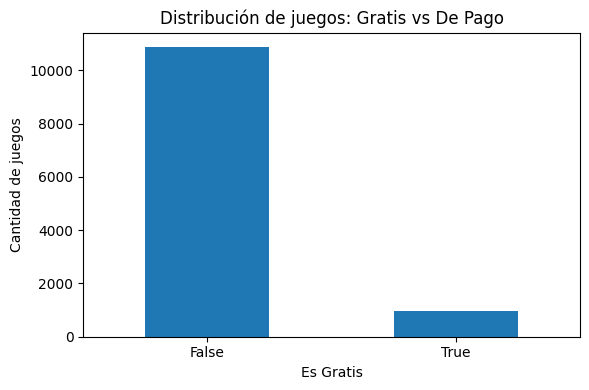

In [0]:
import matplotlib.pyplot as plt

conteo_free = pdf["IsFree"].value_counts()

plt.figure(figsize=(6,4))
conteo_free.plot(kind="bar")
plt.title("Distribución de juegos: Gratis vs De Pago")
plt.xlabel("Es Gratis")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Esta visualización muestra la distribución de juegos gratuitos y de pago dentro del dataset. Se observa que la mayoría de los juegos corresponden a la categoría de pago, mientras que una menor proporción corresponde a juegos gratuitos. Esto permite analizar el modelo de monetización predominante en la plataforma.


VISUALIZACIÓN 2: Lanzamientos por Día de la Semana

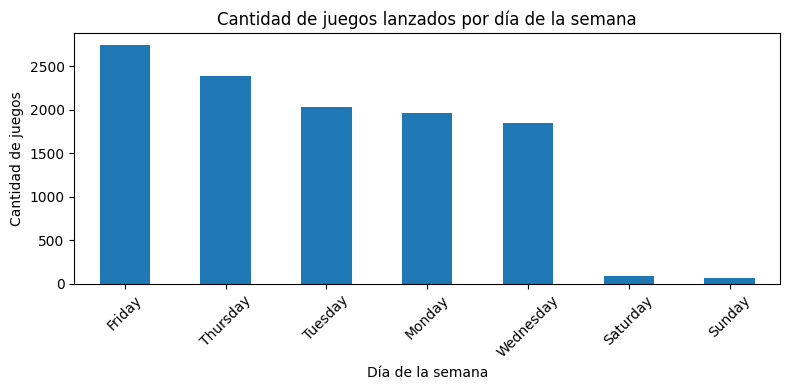

In [0]:
conteo_dias = pdf["nombre_dia"].value_counts()

plt.figure(figsize=(8,4))
conteo_dias.plot(kind="bar")
plt.title("Cantidad de juegos lanzados por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Esta gráfica representa la cantidad de lanzamientos por día de la semana. Se identifican patrones de publicación, observando qué días concentran mayor número de lanzamientos. Esta información es útil para analizar estrategias de publicación en la industria de los videojuegos.


VISUALIZACIÓN 3

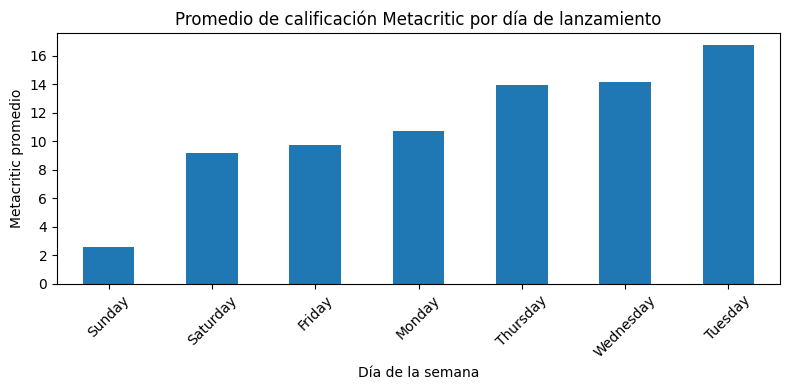

In [0]:
promedio_metacritic = (
    pdf.groupby("nombre_dia")["Metacritic"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,4))
promedio_metacritic.plot(kind="bar")
plt.title("Promedio de calificación Metacritic por día de lanzamiento")
plt.xlabel("Día de la semana")
plt.ylabel("Metacritic promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Este gráfico muestra el promedio de calificaciones Metacritic según el día de lanzamiento del juego. Se puede analizar si existe alguna relación entre el día de publicación y la recepción crítica de los videojuegos.
